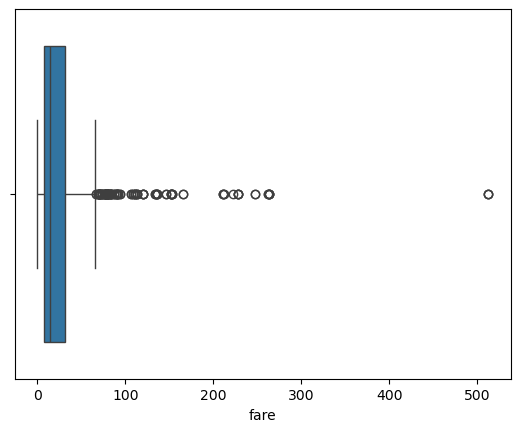

IQR Outliers: 116
Z-score Outliers: 20


In [41]:
"""Detect Outliers
Outliers can:
  -> Distort the mean
  -> Affects standard deviation
  -> Reduce model performance
  -> Influence scaling and regression models
Method 1 : Visual Detection Using box plot
 -> A box plot quickly shows:
1. Minimum value
2. Q1(25th percentile)
3. Median
4. Q3 (75th percentile)
5. Maximum value]
6. Outliers
Method 2 : IQR method
IQR = Interquartile range
formula: IQR = Q3 - Q1
steps: -> Calculate IQR
       -> Calculate limits lower limit and upper limit
       -> Detect Outliers
Method 3: Z-score method
 -> Measures how many standard deviations a value is form the mean.
 steps: -> calculate Z-score
        -> Detect Outliers
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
# Load Titannic dataset
df = sns.load_dataset('titanic')
# Box plot
sns.boxplot(x = df['fare'])
plt.show()
#IQR Method
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = df[(df['fare'] < lower) | (df['fare'] > upper)]
print("IQR Outliers:", len(outliers_iqr))
# Z-Score Method
df['fare_zscore'] = zscore(df['fare'])
outliers_z = df[abs(df['fare_zscore']) >3 ]
print("Z-score Outliers:",len(outliers_z))

In [42]:
"""EDA Important
1. Understand the structure of the dataset
2. Identify missing values
3. Detect Outliers
4. Understand feature distributions
5. Find relationships between variables
6. Check data quality issues
7. Prepare data for machine learning
type:
-> Univariate analysis
-> Numerical Feature
    Mean,median,mode,standard deviation,variance,histogram,box plot
-> categorical features
    value counts, frequency distribution, Bar chart
"""
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("tips")
print(df.head())
print(df.info())
print(df.columns)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [43]:
# 1. Descriptive statistics
print(df['total_bill'].describe())

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


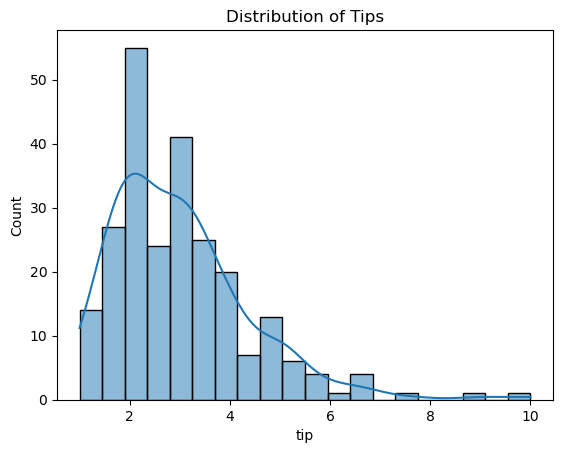

In [44]:
# Histogram
sns.histplot(df['tip'],bins = 20, kde = True)
plt.title("Distribution of Tips")
plt.show()

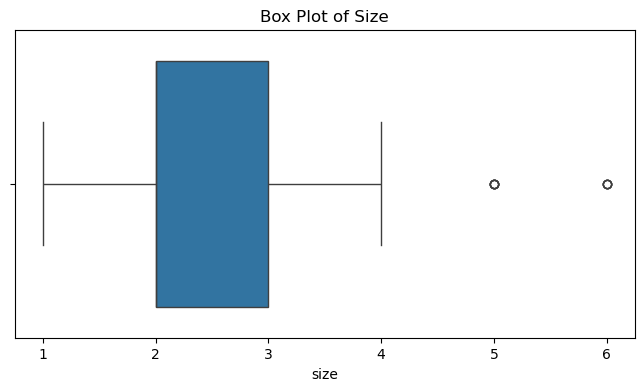

In [45]:
# Box plot
plt.figure(figsize = (8,4))
sns.boxplot(x = df['size'])
plt.title("Box Plot of Size")
plt.show()

In [46]:
# Categorical Value : Day
print(df['day'].value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


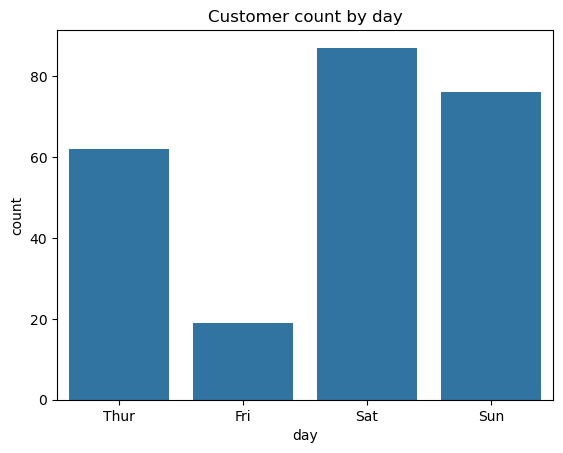

In [47]:
# Count Plot
sns.countplot(x = 'day', data = df)
plt.title("Customer count by day")
plt.show()

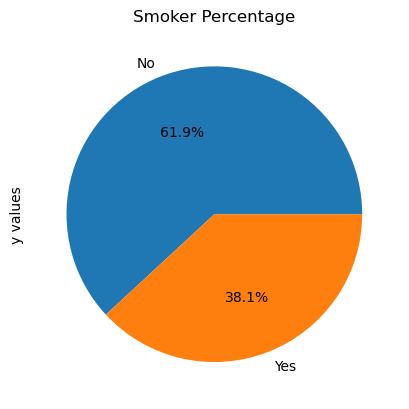

In [48]:
# Pie chart
df['smoker'].value_counts().plot(kind = 'pie',autopct = '%1.1f%%')
plt.title("Smoker Percentage")
plt.ylabel("y values")
plt.show()

In [49]:
#Outlier Detection using IQR
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = df[(df['total_bill'] < lower) | (df['total_bill'] > upper)]
print("IQR Outliers:", len(outliers_iqr))

IQR Outliers: 9


#### Bivariate Analysis

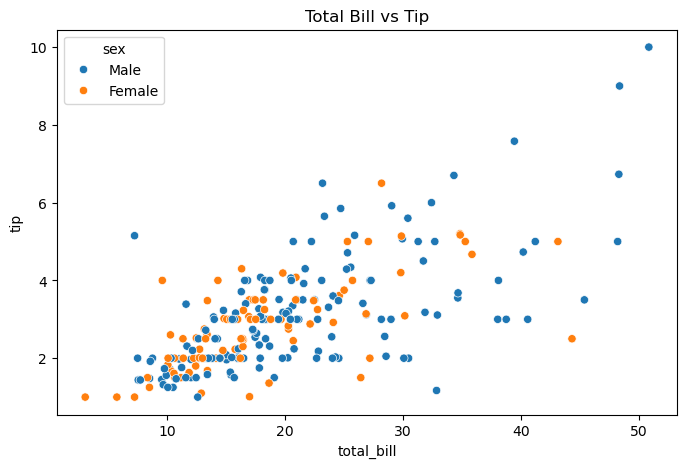

In [50]:
#Bivariate Analysis
""" -> Numerical + Numerical = Scatter Plot
    -> categorical + Numerical = Bar chart
    -> categorical + Categorical = Grouped statistics / crosstab"""
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    data=df
)
plt.title("Total Bill vs Tip")
plt.show()

In [51]:
# Load Dataset
df = sns.load_dataset('tips')

# Pearson Correlation
correlation = df[['total_bill', 'tip']].corr(method='pearson')

print("Pearson Correlation Matrix:")
print(correlation)

Pearson Correlation Matrix:
            total_bill       tip
total_bill    1.000000  0.675734
tip           0.675734  1.000000


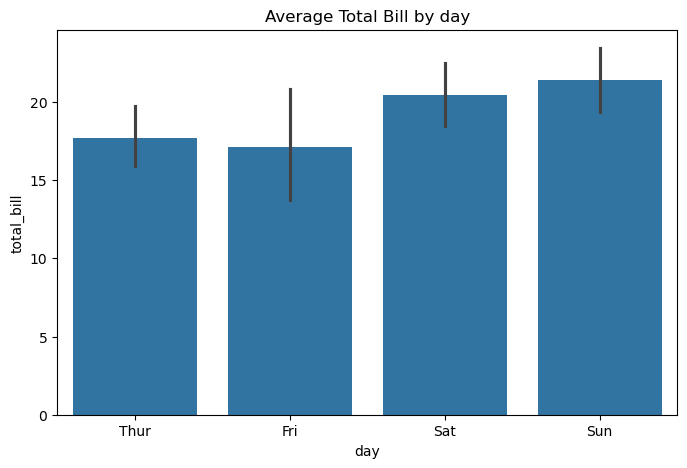

In [52]:
# Bar chart
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.figure(figsize = (8,5))
sns.barplot(
    x = 'day',
    y = 'total_bill',
    data = df
)
plt.title("Average Total Bill by day")
plt.show()

In [53]:
# Grouped Statistics
# Mean Bill by day
print(df.groupby("day",observed = True)["total_bill"].mean())
# Multiple Statistics
print(df.groupby("day",observed = True)["total_bill"].agg(['mean','median','min','max']))

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64
           mean  median   min    max
day                                 
Thur  17.682742   16.20  7.51  43.11
Fri   17.151579   15.38  5.75  40.17
Sat   20.441379   18.24  3.07  50.81
Sun   21.410000   19.63  7.25  48.17


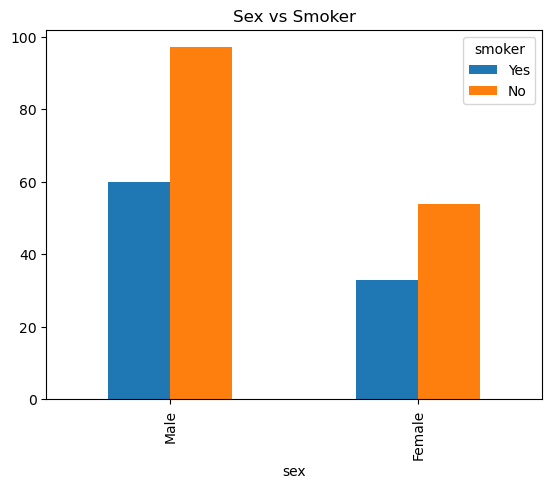

In [54]:
# Bar chart 
pd.crosstab(
    df['sex'],
    df['smoker'],
).plot(kind = 'bar')
plt.title("Sex vs Smoker")
plt.show()

#### Multivariate Analysis

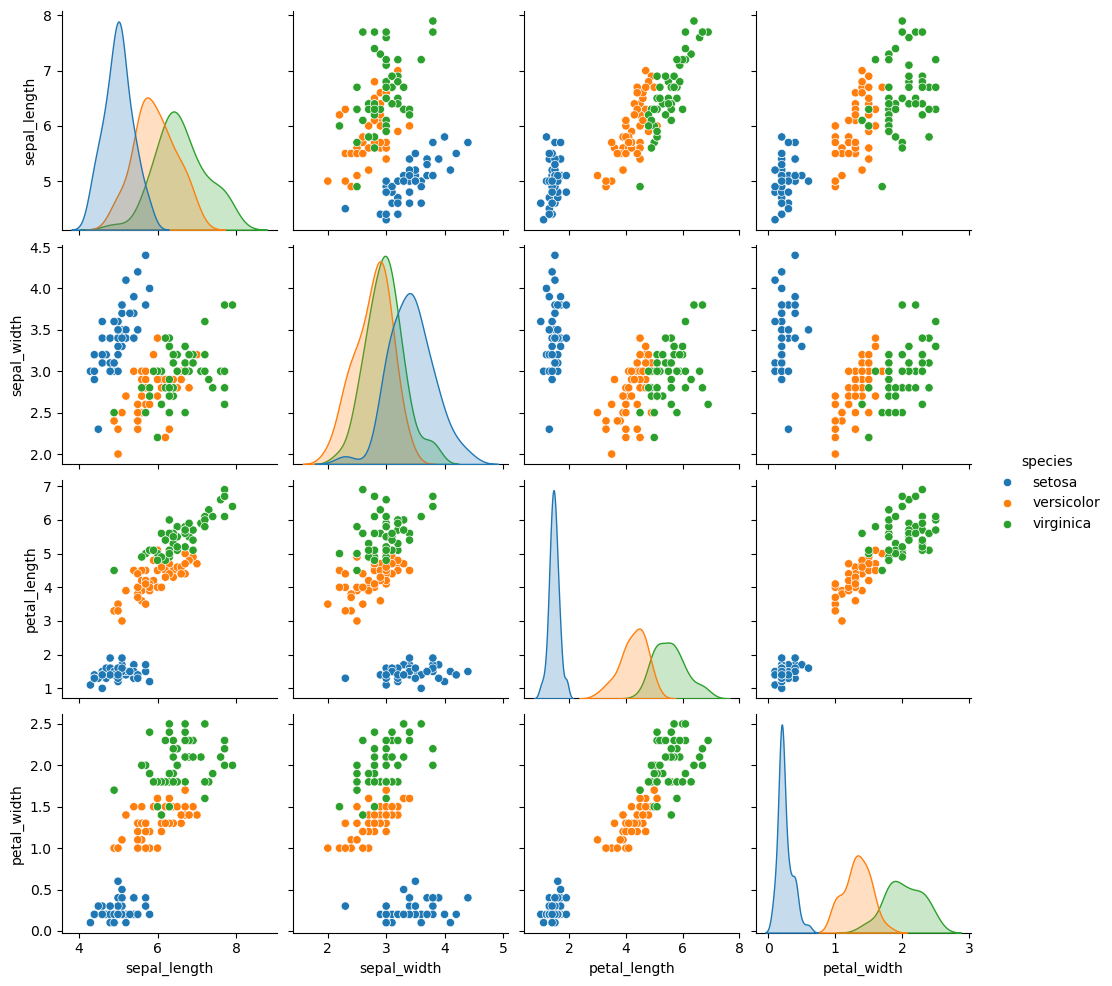

In [55]:
"""Objectives of Multivariate analysis
1. Discover hidden relationships
2. Understand interaction among multiple features
3. Detect clusters and patterns
4. Support feature selection
5. Prepare data for machine learning

Type 
1.Pairplot
2.Color coded scattar plot
3.3D Scattar plot
"""
# 1.Pairplot
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("iris")
sns.pairplot(df,hue = 'species')
plt.show()

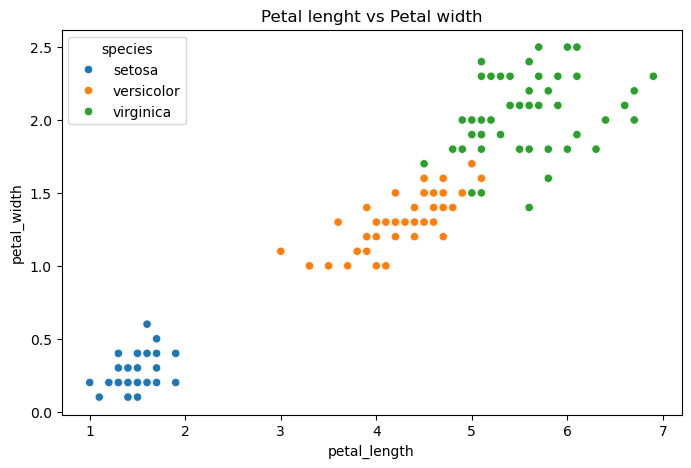

In [56]:
# 2.Color coded scattar plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (8,5))
sns.scatterplot(x = "petal_length", y = "petal_width", hue = "species",data =df)
plt.title("Petal lenght vs Petal width")
plt.show()

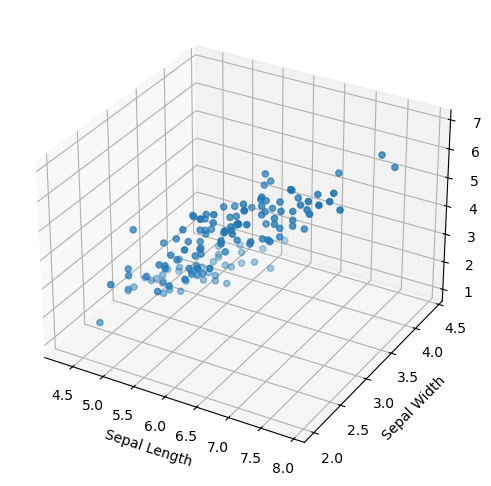

In [57]:
# 3. 3D Scattar plot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(df['sepal_length'],df['sepal_width'],df['petal_length'])
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
plt.show()

### Data Cleaning in csv file 

In [76]:
import pandas as pd

# Load dataset
df = pd.read_csv("all_data_info.csv")

# 1. Basic Information
print("Shape:", df.shape) #How many values in it
print("\nMissing Values:")
print(df.isnull().sum()) # Missing values using null and sum

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Convert Date Column
df['date'] = pd.to_numeric(df['date'], errors='coerce')

# Fill missing dates with median
df['date'] = df['date'].fillna(df['date'].median())

# 4. Handle Missing Values

# Fill categorical columns with mode
df['genre'] = df['genre'].fillna(df['genre'].mode()[0])
df['source'] = df['source'].fillna(df['source'].mode()[0])
df['style'] = df['style'].fillna(df['style'].mode()[0])

# Fill title with "Unknown"
df['title'] = df['title'].fillna("Unknown")

# 5. Clean Text Columns
text_cols = ['artist', 'genre', 'source',
             'style', 'title', 'artist_group']

for col in text_cols:
    df[col] = df[col].str.strip()

# 6. Check Missing Values Again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# 7. Dataset Summary
print("\nDataset Info:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

# 8. Save Cleaned Dataset
df.to_csv("cleaned_all_data_info.csv", index=False)

print("\nDataset cleaned successfully!")


Shape: (103250, 12)

Missing Values:
artist              0
date            26363
genre            1254
pixelsx             0
pixelsy             0
size_bytes          0
source            167
style             986
title             122
artist_group        0
in_train            0
new_filename        0
dtype: int64

Missing Values After Cleaning:
artist          0
date            0
genre           0
pixelsx         0
pixelsy         0
size_bytes      0
source          0
style           0
title           0
artist_group    0
in_train        0
new_filename    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103250 entries, 0 to 103249
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   artist        103250 non-null  object 
 1   date          103250 non-null  float64
 2   genre         103250 non-null  object 
 3   pixelsx       103250 non-null  float64
 4   pixelsy       103250 non-null 

In [59]:
# Correlation analysis
import pandas as pd


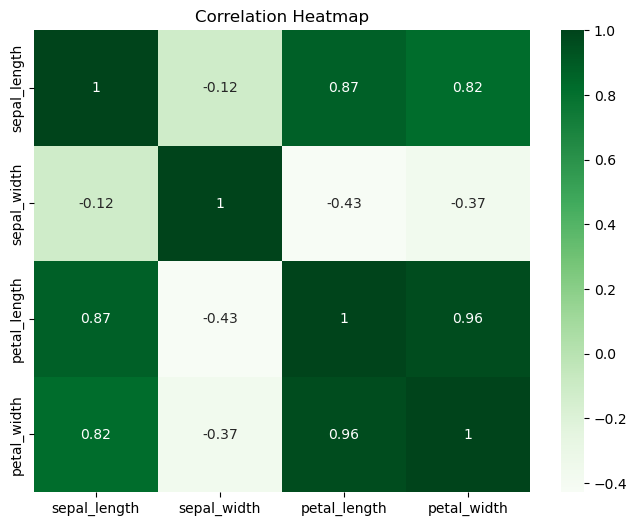

In [60]:
# Correlation heatmap using color
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True),
            annot = True,
            cmap = 'Greens')
plt.title("Correlation Heatmap")
plt.show()

In [71]:
# VIF(Variance Inflation Factor) for Multicollinearity detection 
from statsmodels.stats.outliers_influence import variance_inflation_factor 
x = df.drop('species',axis = 1) 
vif = pd.DataFrame() 
vif['Feature'] = x.columns 
vif["VIF"] = [variance_inflation_factor(x.values,i) 
              for i in range(x.shape[1])] 
print(vif)

        Feature         VIF
0  sepal_length  262.969348
1   sepal_width   96.353292
2  petal_length  172.960962
3   petal_width   55.502060


In [73]:
# Remove a High-VIF Feature
# Suppose we remove petal_length
x_new = x.drop("sepal_length", axis=1)

vif_after = pd.DataFrame()
vif_after["Feature"] = x_new.columns

# Fixed the spelling of variance_inflation_factor and changed X_new to x_new
vif_after["VIF"] = [variance_inflation_factor(x_new.values, i) for i in range(x_new.shape[1])]

print(vif_after)

        Feature        VIF
0   sepal_width   5.856965
1  petal_length  62.071308
2   petal_width  43.292574


In [ ]:
"""# Feature Engineering Recommendations
#Profit Margin
df['Profit_Margin'] = (df['"""

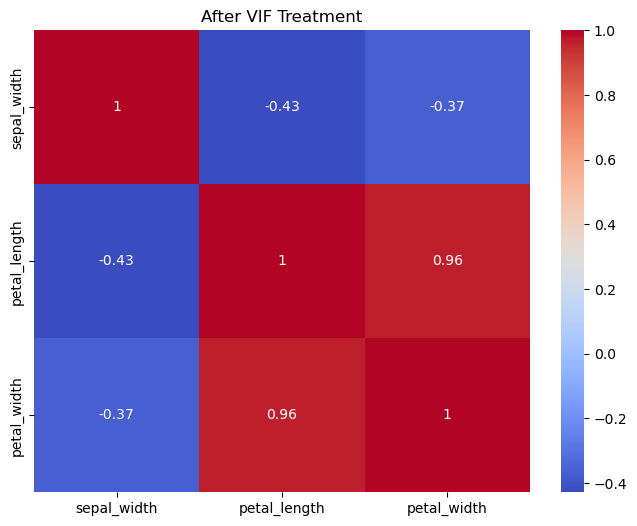

In [75]:
#Heatmap after removing feature
plt.figure(figsize = (8,6))
sns.heatmap(x_new.corr(),annot = True, cmap = "coolwarm")
plt.title("After VIF Treatment")
plt.show()